In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# 1. load Data
df=pd.read_csv('titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Target who will survive on the ship

In [4]:
# Drop the unnecessary columns
# PassengerID
# Name
# Ticket
# Embarked
df = df.drop(['PassengerId','Name', 'Ticket','Embarked'], axis = 1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin
0,0,3,male,22.0,1,0,7.2500,NaN
1,1,1,female,38.0,1,0,71.2833,C85
2,1,3,female,26.0,0,0,7.9250,NaN
3,1,1,female,35.0,1,0,53.1000,C123
4,0,3,male,35.0,0,0,8.0500,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [6]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
dtype: int64

In [7]:
# from the above data we have to drop the cabin column because it have large nan values
# more than 77+%
df = df.drop('Cabin',axis = 1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [7]:
(687/891)*100

77.10437710437711

In [8]:
# now we have nan value in only age column so we will handle it with care
print('Over all Mean Age  = ',df['Age'].mean())
print('Mean age of Female',df[df['Sex']=='female']['Age'].mean())
print('Mean age of Male',df[df['Sex']=='male']['Age'].mean())

Over all Mean Age  =  29.69911764705882
Mean age of Female 27.915708812260537
Mean age of Male 30.72664459161148


In [9]:
df.loc[df['Sex']=='female','Age'] = df.loc[df['Sex']=='female','Age'].fillna(27)
df.loc[df['Sex']=='male','Age'] = df.loc[df['Sex']=='male','Age'].fillna(30)

In [10]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

In [11]:
print('Over all Mean Age  = ',df['Age'].mean())

Over all Mean Age  =  29.580437710437707


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 48.9+ KB


In [12]:
def male_female(x):
    if x == 'male':
        return 1
    else:
        return 0

lambda x : 1 if x=='male' else 0

<function __main__.<lambda>(x)>

In [13]:
df['Gender'] = df['Sex'].apply(lambda x : 1 if x=='male' else 0)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Gender
0,0,3,male,22.0,1,0,7.2500,1
1,1,1,female,38.0,1,0,71.2833,0
2,1,3,female,26.0,0,0,7.9250,0
3,1,1,female,35.0,1,0,53.1000,0
4,0,3,male,35.0,0,0,8.0500,1


In [23]:
df['Gender'] = df['Sex'].apply(male_female)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Gender
0,0,3,male,22.0,1,0,7.2500,1
1,1,1,female,38.0,1,0,71.2833,0
2,1,3,female,26.0,0,0,7.9250,0
3,1,1,female,35.0,1,0,53.1000,0
4,0,3,male,35.0,0,0,8.0500,1


In [14]:
# now we can drop the Sex because we have created a new column gender with numeric value
df = df.drop('Sex', axis = 1)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Gender
0,0,3,22.0,1,0,7.2500,1
1,1,1,38.0,1,0,71.2833,0
2,1,3,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,0,3,35.0,0,0,8.0500,1


<Axes: >

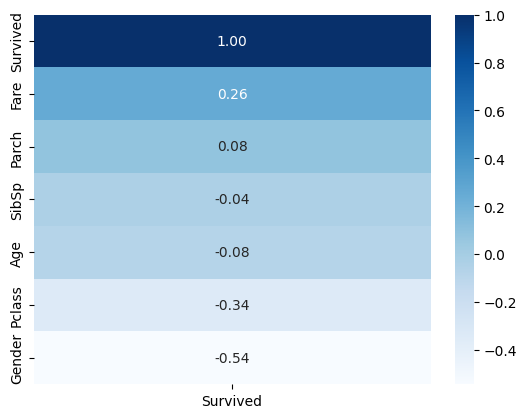

In [16]:
sns.heatmap(df.corr()[['Survived']].sort_values(by='Survived', ascending = False),
           annot = True,
           fmt = '.2f',
           cmap = 'Blues')

In [17]:
# now divide into independent (x) and dependent(y)
x = df.drop('Survived', axis = 1)
y = df['Survived']

In [19]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Gender
0,3,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,0
2,3,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,0
4,3,35.0,0,0,8.0500,1


In [20]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# If you want to do standard scale the data you can and check the accuracy change

In [22]:
# now Split the data into train and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,
                                                    random_state=5052,
                                                   stratify=y)

In [23]:
# Now check the shape of train and test data 
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(668, 6) (223, 6)
(668,) (223,)


In [26]:
# Now import the RandomForest Model and train it 
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()# with its default parameter


In [28]:
# Print the Default parameter
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [29]:
# Train the model
rf.fit(x_train, y_train)

RandomForestClassifier()

In [30]:
rf.score(x_train, y_train)

0.9775449101796407

In [31]:
y_pred = rf.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0], dtype=int64)

In [32]:
# Now do the evaluation of model
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
def model_evaluation(y_actual, y_prediction):
    print('Accuracy_Score = ',accuracy_score(y_actual, y_prediction))
    print('Confusion Matrix \n',confusion_matrix(y_actual, y_prediction))
    sns.heatmap(confusion_matrix(y_actual, y_prediction), annot = True, fmt = '.2f')
    print('Classification_Report \n',classification_report(y_actual, y_prediction))

Accuracy_Score =  0.820627802690583
Confusion Matrix 
 [[120  17]
 [ 23  63]]
Classification_Report 
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       137
           1       0.79      0.73      0.76        86

    accuracy                           0.82       223
   macro avg       0.81      0.80      0.81       223
weighted avg       0.82      0.82      0.82       223



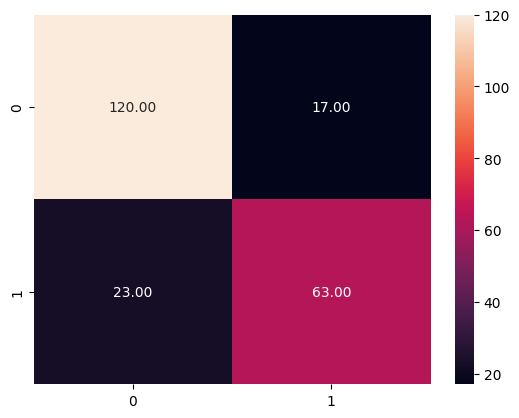

In [33]:
model_evaluation(y_test, y_pred)

# Import model and hyperparameter tuning(GridsearchCV)

In [34]:
# Import Grid SearchCV
from sklearn.model_selection import GridSearchCV
# create a new model
grd_rf = RandomForestClassifier()

In [35]:
grid ={

    'bootstrap': [True],

    'max_depth': [3,80, 90, 5],
    
    'criterion': ['gini','entropy'],

    'max_features': [2, 3],

    'min_samples_leaf': [3, 4, 5],

    'min_samples_split': [8, 10, 12],

    'n_estimators': [100, 200,400]} 

In [36]:
grd_rf = GridSearchCV(grd_rf, param_grid = grid,n_jobs=2,verbose=3, refit = True )

In [37]:
# train for hyperparameter tuning 
grd_rf.fit(x_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(estimator=RandomForestClassifier(), n_jobs=2,
             param_grid={'bootstrap': [True], 'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 80, 90, 5], 'max_features': [2, 3],
                         'min_samples_leaf': [3, 4, 5],
                         'min_samples_split': [8, 10, 12],
                         'n_estimators': [100, 200, 400]},
             verbose=3)

In [40]:
grd_rf.best_params_

{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 90,
 'max_features': 2,
 'min_samples_leaf': 5,
 'min_samples_split': 8,
 'n_estimators': 100}

In [41]:
grd_rf.best_score_

0.8382111996408932

In [42]:
# Creating a new model with best parameters
brf = RandomForestClassifier(bootstrap = True,
 criterion = 'gini',
 max_depth = 90,
 max_features = 2,
 min_samples_leaf = 5,
 min_samples_split = 8,
 n_estimators = 100)# with its default parameter

In [43]:
brf.fit(x_train, y_train)

RandomForestClassifier(max_depth=90, max_features=2, min_samples_leaf=5,
                       min_samples_split=8)

In [44]:
brf.score(x_train, y_train)

0.8892215568862275

In [45]:
y_pred = brf.predict(x_test)

Accuracy_Score =  0.8251121076233184
Confusion Matrix 
 [[122  15]
 [ 24  62]]
Classification_Report 
               precision    recall  f1-score   support

           0       0.84      0.89      0.86       137
           1       0.81      0.72      0.76        86

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.83      0.82       223



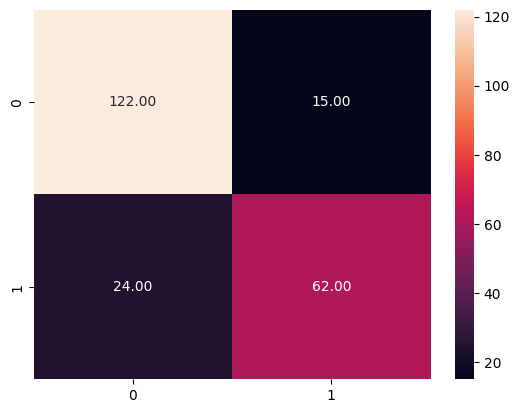

In [46]:
model_evaluation(y_test, y_pred)

In [49]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,Gender
0,3,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,0
2,3,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,0
4,3,35.0,0,0,8.0500,1


In [54]:
rf.predict([[1,25,1,0,72,1]])

C:\Users\DILIP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [38]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Gender
0,0,3,22.0,1,0,7.2500,1
1,1,1,38.0,1,0,71.2833,0
2,1,3,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,0,3,35.0,0,0,8.0500,1


In [55]:
# Extract the model
import pickle
pickle.dump(rf,open('aditi_rf.pkl','wb'))

In [54]:
# Now load the  saved model
model = pickle.load(open('rf.pkl', 'rb'))
model

RandomForestClassifier()